# Random Forest Classification

## Importing the libraries

In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

## Importing the dataset

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv("Employee_Performance_Retention.csv")
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df['Attrition'] = df['Attrition'].map({'No': 0, 'Yes': 1})
X = df.drop(['Employee_ID', 'Attrition'], axis=1)
y = df['Attrition']

## Splitting the dataset into the Training set and Test set

In [13]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## Feature Scaling

In [14]:

numerical_cols = X_train.select_dtypes(include=np.number).columns
categorical_cols = X_train.select_dtypes(include='object').columns
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough'
)
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)
ohe_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
all_feature_names = list(numerical_cols) + list(ohe_feature_names)
try:
    age_scaled_index = all_feature_names.index('Age')
    years_exp_scaled_index = all_feature_names.index('Years_of_Experience')
except ValueError as e:
    print(f"Could not find index for Age or Years_of_Experience after one-hot encoding: {e}")
    age_scaled_index = None
    years_exp_scaled_index = None


print("Feature scaling applied.")

Feature scaling applied.


## Training the Random Forest Classification model on the Training set

In [26]:
from imblearn.over_sampling import SMOTE # Import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline # Import imblearn's Pipeline
from sklearn.metrics import average_precision_score # Import average_precision_score

rf = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)

pipeline = ImbPipeline([ # Use ImbPipeline
    ('preproc', preprocessor),
    ('smote', SMOTE(random_state=42)), # Add SMOTE here
    ('clf', rf)
])
param_dist = {
    "clf__criterion": ["gini", "entropy", "log_loss"],
    "clf__n_estimators": [100, 300, 500],
    "clf__max_depth": [10, 20, 30, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2", None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=cv,
    scoring="f1", # Changed scoring back to f1 as it's more appropriate for imbalanced data
    n_jobs=-1,
    verbose=2,
    random_state=42
)

search.fit(X_train, y_train)
# Remove the separate imblearn pipeline as SMOTE is now in the main pipeline
# from imblearn.over_sampling import SMOTE
# from imblearn.pipeline import Pipeline as ImbPipeline

# imb_pipeline = ImbPipeline([
#     ('preproc', preprocessor),
#     ('smote', SMOTE(random_state=42)),
#     ('clf', rf)
# ])

best_model = search.best_estimator_

y_pred_default = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("--- Evaluation with Default Threshold (0.5) ---")
print("Best Parameters:", search.best_params_)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_default):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Test PR-AUC: {average_precision_score(y_test, y_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_default))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_default))

# Evaluate with new threshold (0.8)
new_threshold = 0.8
y_pred_new_threshold = (y_proba >= new_threshold).astype(int)

print("\n--- Evaluation with Threshold (0.8) ---")
print(f"Test Accuracy (Threshold 0.8): {accuracy_score(y_test, y_pred_new_threshold):.4f}")
print(f"Test ROC-AUC (Threshold 0.8): {roc_auc_score(y_test, y_proba):.4f}") # ROC-AUC doesn't change with threshold
print(f"Test PR-AUC (Threshold 0.8): {average_precision_score(y_test, y_proba):.4f}") # PR-AUC doesn't change with threshold
print("\nClassification Report (Threshold 0.8):\n", classification_report(y_test, y_pred_new_threshold))
print("Confusion Matrix (Threshold 0.8):\n", confusion_matrix(y_test, y_pred_new_threshold))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
--- Evaluation with Default Threshold (0.5) ---
Best Parameters: {'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': 10, 'clf__criterion': 'gini'}
Test Accuracy: 0.5972
Test ROC-AUC: 0.5248
Test PR-AUC: 0.2088

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.65      0.72      1449
           1       0.21      0.37      0.27       351

    accuracy                           0.60      1800
   macro avg       0.51      0.51      0.49      1800
weighted avg       0.69      0.60      0.63      1800

Confusion Matrix:
 [[944 505]
 [220 131]]

--- Evaluation with Threshold (0.8) ---
Test Accuracy (Threshold 0.8): 0.8050
Test ROC-AUC (Threshold 0.8): 0.5248
Test PR-AUC (Threshold 0.8): 0.2088

Classification Report (Threshold 0.8):
               precision    recall  f1-score   support

       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
import joblib
joblib.dump(best_model, 'random_forest_model.joblib')
print("Model saved as random_forest_model.joblib")

Model saved as random_forest_model.joblib


## Predicting the Test set results

In [16]:
y_pred = best_model.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.values.reshape(len(y_test),1)),1))

[[1 0]
 [1 0]
 [0 1]
 ...
 [0 0]
 [1 1]
 [0 0]]


## Making the Confusion Matrix

In [17]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[944 505]
 [220 131]]


0.5972222222222222

## Visualising the Training set results

/tmp/ipython-input-2700979175.py:41: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, age_scaled_index], X_set[y_set == j, years_exp_scaled_index],


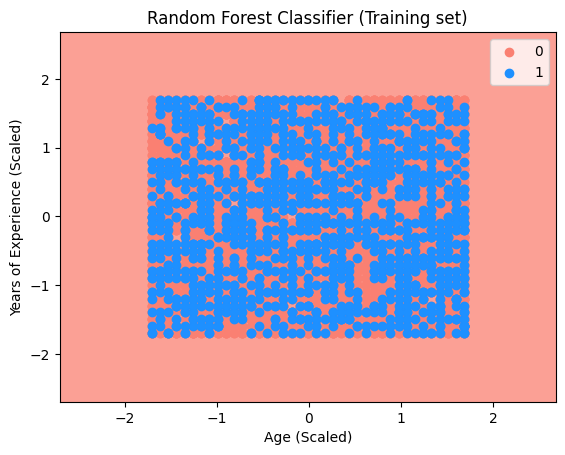

In [24]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

numerical_cols_list = list(numerical_cols)
age_original_index = numerical_cols_list.index('Age')
years_exp_original_index = numerical_cols_list.index('Years_of_Experience')

preprocessor.fit(X_train)

X_set, y_set = preprocessor.transform(X_train), y_train

X1, X2 = np.meshgrid(np.arange(start=X_set[:, age_scaled_index].min() - 1, stop=X_set[:, age_scaled_index].max() + 1, step=0.01),
                     np.arange(start=X_set[:, years_exp_scaled_index].min() - 1, stop=X_set[:, years_exp_scaled_index].max() + 1, step=0.01))
X_grid_df = pd.DataFrame(index=range(X1.size), columns=X_train.columns)
for col in numerical_cols:
    X_grid_df[col] = X_train[col].mean()
for col in categorical_cols:
    X_grid_df[col] = X_train[col].mode()[0]
X_grid_df['Age'] = X1.ravel()
X_grid_df['Years_of_Experience'] = X2.ravel()

X_grid_transformed = preprocessor.transform(X_grid_df)

Z = best_model['clf'].predict(X_grid_transformed).reshape(X1.shape)

plt.contourf(X1, X2, Z, alpha=0.75, cmap=ListedColormap(['#FA8072', '#1E90FF']))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, age_scaled_index], X_set[y_set == j, years_exp_scaled_index],
                c=ListedColormap(['#FA8072', '#1E90FF'])(i), label=j)

plt.title('Random Forest Classifier (Training set)')
plt.xlabel('Age (Scaled)')
plt.ylabel('Years of Experience (Scaled)')
plt.legend()
plt.show()

## Visualising the Test set results

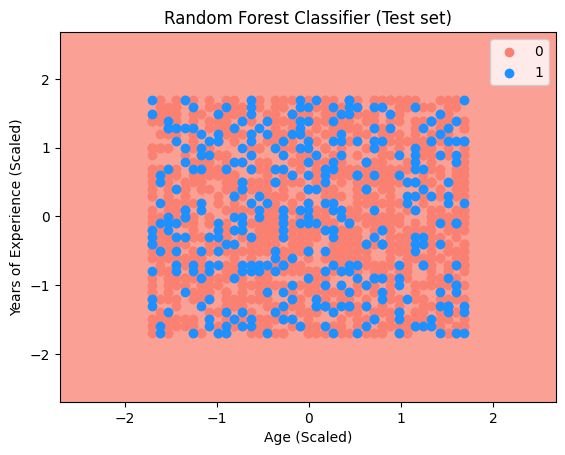

In [25]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

numerical_cols_list = list(numerical_cols)
age_original_index = numerical_cols_list.index('Age')
years_exp_original_index = numerical_cols_list.index('Years_of_Experience')

preprocessor.fit(X_train)

X_set, y_set = preprocessor.transform(X_test), y_test

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, age_scaled_index].min() - 1, stop=X_set[:, age_scaled_index].max() + 1, step=0.01),
    np.arange(start=X_set[:, years_exp_scaled_index].min() - 1, stop=X_set[:, years_exp_scaled_index].max() + 1, step=0.01)
)

X_grid_df = pd.DataFrame(index=range(X1.size), columns=X_train.columns)

for col in numerical_cols:
    X_grid_df[col] = X_train[col].mean()

for col in categorical_cols:
    X_grid_df[col] = X_train[col].mode()[0]

X_grid_df['Age'] = X1.ravel()
X_grid_df['Years_of_Experience'] = X2.ravel()

X_grid_transformed = preprocessor.transform(X_grid_df)

Z = best_model['clf'].predict(X_grid_transformed).reshape(X1.shape)

plt.contourf(X1, X2, Z, alpha=0.75, cmap = ListedColormap(['#FA8072', '#1E90FF']) )
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
colors = ['#FA8072', '#1E90FF']
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, age_scaled_index], X_set[y_set == j, years_exp_scaled_index],
        color=colors[i], label = j
    )
plt.title('Random Forest Classifier (Test set)')
plt.xlabel('Age (Scaled)')
plt.ylabel('Years of Experience (Scaled)')
plt.legend()
plt.show()